In [1]:
'''
graph # of packets by chip. This is a quick way to check for missing packets when
using pedestal mode
'''

###############################
# Imports
###############################

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from matplotlib.ticker import PercentFormatter, FixedFormatter, FixedLocator

###############################
# Initialize
###############################

#filename = "../data/packet-warm_lin_t2_10kcycles_600s_9.7sramp.hdf5"
filename = "../data/packet-warm_lin_t2_file2_10kcycles_600s.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
#tiles = [1,2,3,4,5,6,7,8,9,10]
tiles = [2]

# serial numbers for set 1 of tiles 1-10
#chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for set 2 of tiles 1-10
chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]

# initialize variables
first_tile = True
unique_io_channels = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
                     ]
    
    return io_ch_per_tile[tile]

In [3]:
def get_data(filename):
    
    global tally, receipt_ts, bad_chip_count, missing, pkt_count, first_tile, unique_io_channels
    global problem_chip_pair, tiles, chip_serial_number_list, highest_ts
    
    # initialize at tile level
    npkts = 0
    first_problem_chip = True
    
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]

    # determine the time period for this data file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
        
    # mask for data packets
    data_mask     = packets['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))

    for tile in tiles:
    
        print(f"\n\n############################ Checking Tile {tile} ###################################")
        print(f"Run Statistics:")
    
        # initialize for the tile
        pkt_count = np.zeros(256)
        chip_list, npkts_chip_list, nzeros_chip_list, nmax_chip_list = [], [], [], []
        
        # get a list of the io_channels that could be enabled for a given tile, and then determine which
        # ones were enabled
        io_channel_ids = get_io_channels(tile)
        enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
        
        # mask for the chosen tile
        tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
        tile_pkts = data_pkts[tile_mask]

        max_word = max(tile_pkts['dataword'])
        
        if len(tile_pkts) == 0: 
            print(f'There are no data packets for tile {tile}')        
            return
        
        print(f"\t{len(tile_pkts):,} data packets were collected from tile {tile}")
        print(f"\t{max_word} was the highest dataword, probably the dataword registering an overflow")
        
    #######################################################################################
    # count # of pkts in each chip
    #######################################################################################
        
        for chip in range(11,171):
            
            # mask for chip
            chip_mask = tile_pkts['chip_id']==chip
            chip_pkts = tile_pkts[chip_mask]
            chip_words = chip_pkts['dataword']

            # count # of packets, # of zero or max datawords
            npkts = len(chip_pkts)
            nzeros = chip_words.tolist().count(0)
            nmax   = chip_words.tolist().count(max_word)
        
            # create lists for graphine
            npkts_chip_list.append(npkts)
            nzeros_chip_list.append(nzeros)
            nmax_chip_list.append(nmax)
            chip_list.append(chip)

        mean_npkts = np.mean(npkts_chip_list)
        stdev_npkts = np.std(npkts_chip_list)
        
        fig, ax = plt.subplots(1,2,figsize=(16, 3))

        ax[0].set_title(f'Tile {tile}: # of Packets by Chip\nMean {mean_npkts:.0f}, Stdev {stdev_npkts:.0f} \nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax[0].bar(chip_list, npkts_chip_list)
        ax[0].set_xlabel("Chip")
        ax[0].set_ylabel("# Packets")
        ax[0].set_yscale("log")

        ax[1].set_title(f'Tile {tile}: # of Packets by Chip\nMean {mean_npkts:.0f}, Stdev {stdev_npkts:.0f} \nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax[1].hist(npkts_chip_list, bins=500)
        ax[1].set_ylabel("# chips")
        ax[1].set_xlabel("# Packets")
        ax[1].set_yscale("log")        
        plt.show

        fig, ax = plt.subplots(1,2,figsize=(16, 3))
        
        ax[0].set_title(f'Tile {tile}: # of Zero Datawords by Chip\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax[0].bar(chip_list, nzeros_chip_list)
        ax[0].set_xlabel("Chip")
        ax[0].set_ylabel("# Zero Datawords")
        ax[0].set_yscale("log")

        ax[1].set_title(f'Tile {tile}: # of Overflow Datawords by Chip \n Benchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax[1].bar(chip_list, nmax_chip_list)
        ax[1].set_ylabel("# of Max Datawords")
        ax[1].set_xlabel("Chip")
        ax[1].set_yscale("log")        
        plt.show
            
    return 



############################ Checking Tile 2 ###################################
Run Statistics:
	68,048,412 data packets were collected from tile 2
	1023 was the highest dataword, probably the dataword registering an overflow


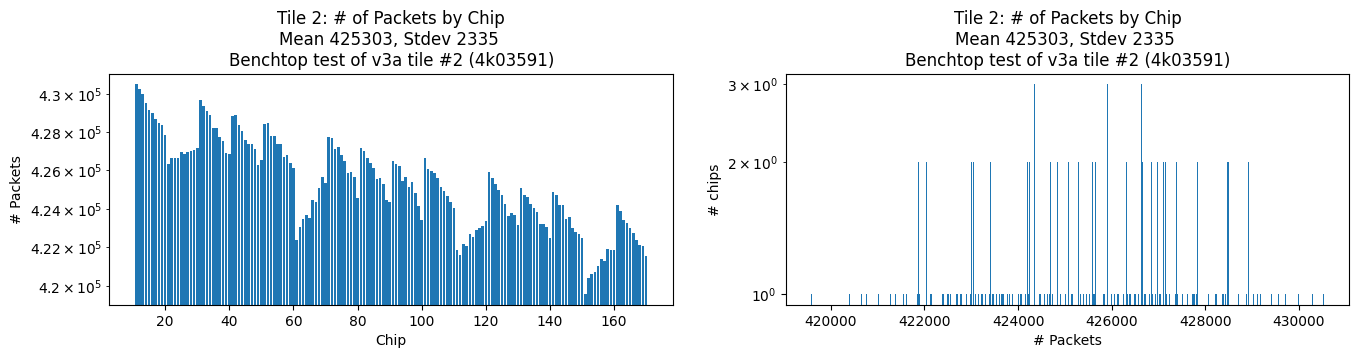

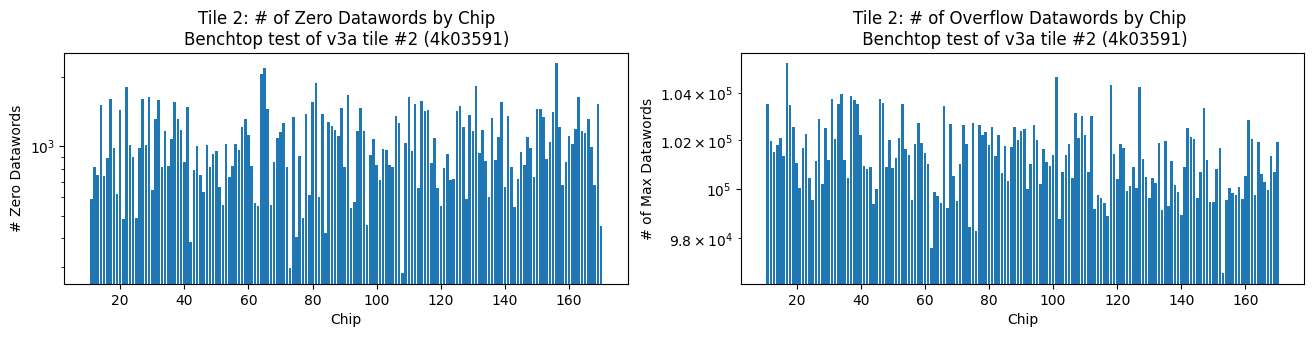

In [4]:
####################
# main
####################

get_data(filename)
